# Transformations, automatic feature selection, and expert knowledge
- Univariate nonlinear transformations
- Automatic feature selection
- Model-based feature selection
- Using expert knowledge in feature engineering
---
# Key ideas
Feature engineering is not only about adding more variables.

It is also about:

1. representing variables in a form the model can use better
2. keeping only useful variables
3. bringing domain knowledge into the feature space

This is especially important in social-science and survey applications, where variables may be:
- skewed
- categorical
- noisy
- high-dimensional
- theoretically meaningful but not directly model-ready

## 1. Imports

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.feature_selection import SelectPercentile, f_regression, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.datasets import load_breast_cancer


# Part I: Univariate Nonlinear Transformations

A linear model assumes a linear relation between each feature and the target.

But sometimes the raw variable is badly scaled or highly skewed.

Then a simple transformation such as:

- `log`
- `sqrt`
- `exp`
- `sin`
- `cos`

can make the relationship easier to model.

---
## Why transformations help

If a feature is:
- strongly skewed
- spread over a very large range
- count-like and strictly nonnegative
- periodic

then transforming it can improve how the model sees structure.

A very common case is count data. Counts are nonnegative and often right-skewed, so a `log(1+x)` transformation can make them much more regular.

## 2. Example: count-like features and log transformation


In [188]:
rng = np.random.RandomState(0)

X_org = rng.normal(size=(1000, 3))
w = rng.normal(size=3)

X = rng.poisson(10 * np.exp(X_org))

y = np.dot(X_org, w) + rng.normal(scale=0.5, size=1000)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X[:5])

X shape: (1000, 3)
y shape: (1000,)

First 5 rows of X:
[[56 18 27]
 [81 57  3]
 [25  9 11]
 [20 13 30]
 [27 13 13]]


These features are positive integers and strongly skewed. 
Now compare the first feature before and after a log transformation.

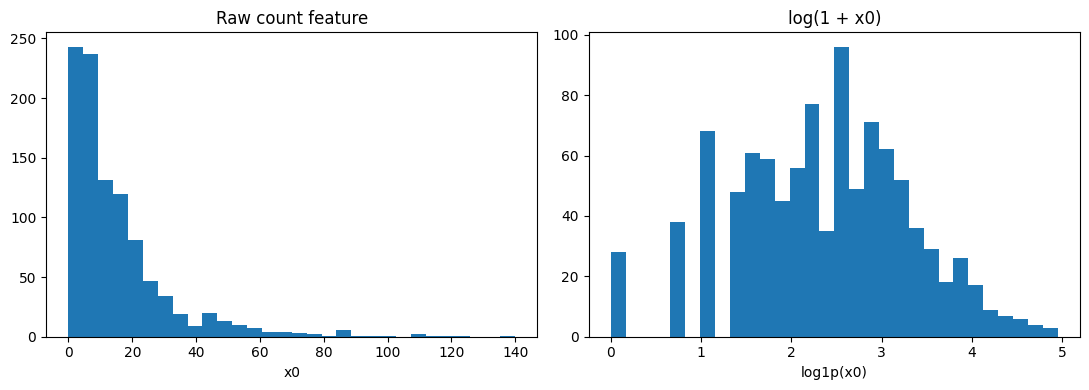

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(X[:, 0], bins=30)
axes[0].set_title("Raw count feature")
axes[0].set_xlabel("x0")

axes[1].hist(np.log1p(X[:, 0]), bins=30)
axes[1].set_title("log(1 + x0)")
axes[1].set_xlabel("log1p(x0)")

plt.tight_layout()
plt.show()

The `log1p` transformation:
$log(1+x)$

is especially useful because:
- it works when zeros are present
- it compresses large values
- it often makes skewed count variables more regular

## 3. Compare linear regression on raw vs transformed features

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

lr_raw = LinearRegression().fit(X_train, y_train)
pred_raw = lr_raw.predict(X_test)

X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)

lr_log = LinearRegression().fit(X_train_log, y_train)
pred_log = lr_log.predict(X_test_log)

print("R^2 with raw counts:", round(r2_score(y_test, pred_raw), 3))
print("R^2 with log-transformed X:", round(r2_score(y_test, pred_log), 3))


R^2 with raw counts: 0.532
R^2 with log-transformed X: 0.793


## Interpretation

The target here was generated from teh latent Gaussian variables `X_org`, not directly from the obsered skewed counts.

So the raw counts are a distorted representation of the underlying signal.

Applying `log1p` partly undoes that distortion, making the relation more linear and easier for linear regression to capture.

A transformation does not change the data-generating process, but it can create a more model-friendly representation.

---

## 4. Using `FunctionTransformer` in a pipeline



In [191]:
log_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")

pipe = make_pipeline(
    log_transformer,
    LinearRegression()
)

pipe.fit(X_train, y_train)
pred_pipe = pipe.predict(X_test)

print("R^2 from pipeline with log1p:", round(r2_score(y_test, pred_pipe), 3))



R^2 from pipeline with log1p: 0.793


# Part II: Automatic feature selection

Feature selection means choosing a subset of variables.

This can help when:

- there are many noisy predictors
- some variables are irrelevant
- we want a simpler model
- we want better interpretability

There are several approaches. Here we focus on:

1. univariate automatic feature selction
2. model-based feature selection

## 5. Synthetic regression example with informative and noisy features


In [192]:
rng = np.random.RandomState(0)

n_samples = 300
n_features = 40
n_informative = 5

X = rng.normal(size=(n_samples, n_features))
true_coef = np.zeros(n_features)
true_coef[:n_informative] = [2.5, -1.8, 1.2, 0.8, -2.2]

y = X @ true_coef + rng.normal(scale=1, size=n_samples)

print("X shape:", X.shape)
print("Number of truly informative features:", np.sum(true_coef != 0))


X shape: (300, 40)
Number of truly informative features: 5


## 6. Univariate feature selection with `SelectPercentile`

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# keep the best 25% of features according to univariate F-test
select = SelectPercentile(score_func=f_regression, percentile=25)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)
X_test_selected = select.transform(X_test)

print("Original shape:", X_train.shape)
print("Selected shape:", X_train_selected.shape)

selected_mask = select.get_support()
print("Selected feature indices:", np.where(selected_mask)[0])


Original shape: (225, 40)
Selected shape: (225, 10)
Selected feature indices: [ 0  1  2  3  4 11 15 20 22 24]


For each feature separately, it asks:

How strongly is this variable related to the target?

Then it keeps the top-ranked variables.

### Important limitation

This is a univariate method.
It ignores joint structure among variables. A feature may be weak on its own but useful together with others.



In [194]:
lr_all = LinearRegression().fit(X_train, y_train)
pred_all = lr_all.predict(X_test)

lr_selected = LinearRegression().fit(X_train_selected, y_train)
pred_selected = lr_selected.predict(X_test_selected)

print("R^2 using all features:     ", round(r2_score(y_test, pred_all), 3))
print("R^2 after feature selection:", round(r2_score(y_test, pred_selected), 3))


R^2 using all features:      0.921
R^2 after feature selection: 0.924


## 7. Visualize which features were selected

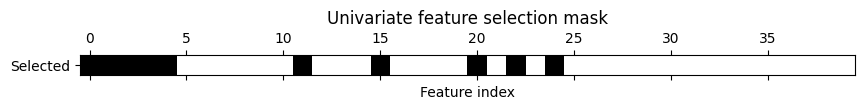

In [195]:
plt.figure(figsize=(10, 2.5))
plt.matshow(selected_mask.reshape(1, -1), cmap="gray_r", fignum=False)
plt.xlabel("Feature index")
plt.yticks([0], ["Selected"])
plt.title("Univariate feature selection mask")
plt.show()

# Part III. Model-based feature selection

Instead of evaluating each feature separately, we can let a model decide which features matter.

Typical examples:
- Lasso
- tree-based models
- linear models with sparse coefficients

The adavantage is that model-based selection can use **joint information** across features.

# 8. Model-based selection with Lasso

In [196]:
lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.05, random_state=0, max_iter=10000)
)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("R^2 with Lasso:", round(r2_score(y_test, pred_lasso), 3))

R^2 with Lasso: 0.923


Lasso performs both:
- regression
- feature selection

Because it can shrink some coefficients exactly to zero.

In [197]:
lasso_model = lasso.named_steps["lasso"]
nonzero = np.where(lasso_model.coef_ != 0)[0]

print("Nonzero coefficient indices:", nonzero)
print("Number selected:", len(nonzero))
print("Coefficients:")
print(lasso_model.coef_[nonzero])


Nonzero coefficient indices: [ 0  1  2  3  4  5  8 10 11 15 17 18 19 20 21 26 27 28 33 35 36 37]
Number selected: 22
Coefficients:
[ 2.21143739e+00 -1.77175957e+00  1.17874605e+00  7.50863160e-01
 -2.12175740e+00  7.54449188e-02 -1.89139865e-02  5.79499714e-02
  6.09724984e-02 -5.22037917e-02 -1.81364893e-02 -3.16828703e-04
  3.94828880e-02 -1.60482629e-01  1.08073381e-01  8.44113968e-03
 -4.57721689e-02 -8.25383622e-02 -4.41595565e-02  5.21348330e-02
  1.74535043e-02  3.32199021e-02]


## 9. `SelectFromModel`: using a fitted model as a selector

In [198]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)

selector = SelectFromModel(
    Lasso(alpha=0.05, random_state=0, max_iter=10000)
)

selector.fit(X_train_scaled, y_train)

selected_mask_model = selector.get_support()
print("Selected features by model-based selection:", np.where(selected_mask_model)[0])




Selected features by model-based selection: [ 0  1  2  3  4  5  8 10 11 15 17 18 19 20 21 26 27 28 33 35 36 37]


## 10. Classification example: model_based feature selection on breast cancer data

In [199]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

print("Accuracy with all features:", round(rf.score(X_test, y_test), 3))



Accuracy with all features: 0.944


In [200]:
selector = SelectFromModel(
    rf
)
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print("Original shape:", X_train.shape)
print("Selected shape:", X_train_selected.shape)

rf_selected = RandomForestClassifier(n_estimators=100, random_state=0)
rf_selected.fit(X_train_selected, y_train)

print("Accuracy after model-based selection:", round(rf_selected.score(X_test_selected, y_test), 3))


Original shape: (426, 30)
Selected shape: (426, 8)
Accuracy after model-based selection: 0.944


## Interpretation

Tree-based models provide feature importances.
`SelectFromModel` uses those importances to keep the most relevant variables.

This is a model-based selection method, not a univariate screening method.

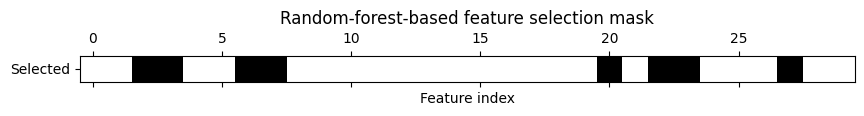

In [201]:
selected_mask_rf = selector.get_support()

plt.figure(figsize=(10, 2.5))
plt.matshow(selected_mask_rf.reshape(1, -1), cmap="gray_r", fignum=False)
plt.xlabel("Feature index")
plt.yticks([0], ["Selected"])
plt.title("Random-forest-based feature selection mask")
plt.show()

# Part IV. Using expert knowledge

Not all useful features come from automatic procedures.
Sometimes the best features come from:
- theory
- measurement knowledge
- domain expertise
- knowledge of the dat collection process

## 11. Why expert knowledge matters in social data

In social-science data, raw variables often do not align neatly with theoretical concetps.

Examples:
- age may matter nonlinearly, so use `age` and `age^2`
- income may be highly skewed, so use `log(income)`
- month of interview may be seasonal, so cyclical coding may be better than raw month numbers
- repeated responses may need aggregation into sclaes or latent variables
- item nonresponse may itself be informative

Automatic feature selection may miss these theoretically meaningful respresentations.

## 12. Small example: expert feature engineering beats raw respresentation

In [202]:
rng = np.random.RandomState(42)

n = 300
age = rng.normal(18, 80, size=n)

y = -0.01 * (age - 45)**2 + 5 + rng.normal(scale=0.5, size=n)

df = pd.DataFrame({"age": age, "y": y})
df.head()

,age,y
0,57.737132,2.963157
1,6.938856,-9.766597
2,69.815083,-0.784237
3,139.842389,-84.645601
4,-0.732270,-15.924856


In [203]:
X_raw = df[["age"]].values
y = df["y"].values

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, random_state=0)

#Model 1: raw age only
lr_raw = LinearRegression().fit(X_train, y_train)
pred_raw = lr_raw.predict(X_test)

#Model 2: expert knowledge -> add age^2
X_train_expert = np.column_stack([X_train[:, 0], X_train[:, 0]**2])
X_test_expert = np.column_stack([X_test[:, 0], X_test[:, 0]**2])

lr_expert = LinearRegression().fit(X_train_expert, y_train)
pred_expert = lr_expert.predict(X_test_expert)

print("R^2 with raw age only:   ", round(r2_score(y_test, pred_raw), 3))
print("R^2 with age and age^2: ", round(r2_score(y_test, pred_expert), 3))


R^2 with raw age only:    0.148
R^2 with age and age^2:  1.0


### Interpretation

No automatic selector was needed here.

The key improvement came from **theoretical knowledge**:

> age may have a nonlinear relation with the outcome.

This is exactly the kind of insight that feature engineering often depends on.

## Example: How Different Time Representations Affect Model Performance

- Time is represented as a single increasing numeric variable (seconds since epoch).
- This representation ignores the inherent periodic structure of time.
- Both linear and tree-based models perform poorly.

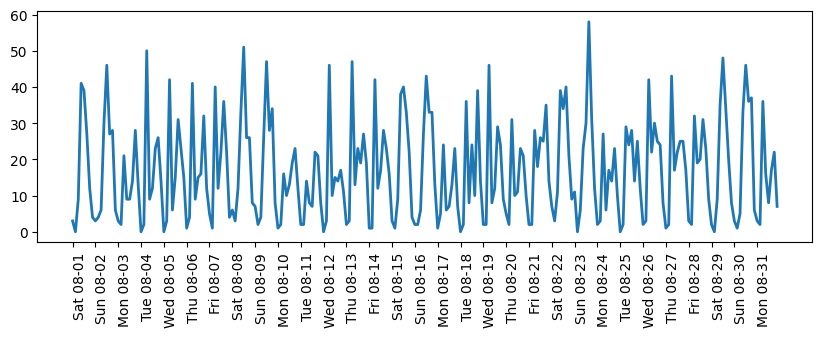

In [204]:
from mglearn.datasets import load_citibike
citibike = load_citibike()

citibike.head()

plt.figure(figsize=(10, 3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(), freq="D")
plt.xticks(xticks, xticks.strftime("%a %m-%d"), rotation=90, ha="left")
plt.plot(citibike, linewidth=2)

In [205]:

X = citibike.index.view("int64") // 10**9
X = X.reshape(-1, 1)

from sklearn.ensemble import RandomForestRegressor

n_train = 184

def eval_on_features(features, target, regressor):
    X_train, X_test = features[:n_train], features[n_train:]
    y_train, y_test = target[:n_train], target[n_train:]
    regressor.fit(X_train, y_train)
    print("Test-set R^2: ", regressor.score(X_test, y_test))
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    plt.figure(figsize=(10, 3))
    plt.xticks(range(0, len(X), 8), xticks.strftime("%a %m-%d"), rotation=90, ha="left");
    plt.plot(range(n_train), y_train, label="train", linewidth=2)
    plt.plot(range(n_train, len(y_test) + n_train), y_test, label="test", linewidth=2)
    plt.plot(range(n_train), y_pred_train, label="prediction train", linewidth=2)
    plt.plot(range(n_train, len(y_test) + n_train), y_pred, label="prediction test", linewidth=2)
    plt.legend(loc=(1.01, 0))

regressor = RandomForestRegressor(n_estimators=100, random_state=0)
plt.figure()
eval_on_features(X, y, regressor)


ValueError: Found input variables with inconsistent numbers of samples: [116, 64]

<Figure size 640x480 with 0 Axes>

Test-set R^2:  0.5995775993305429


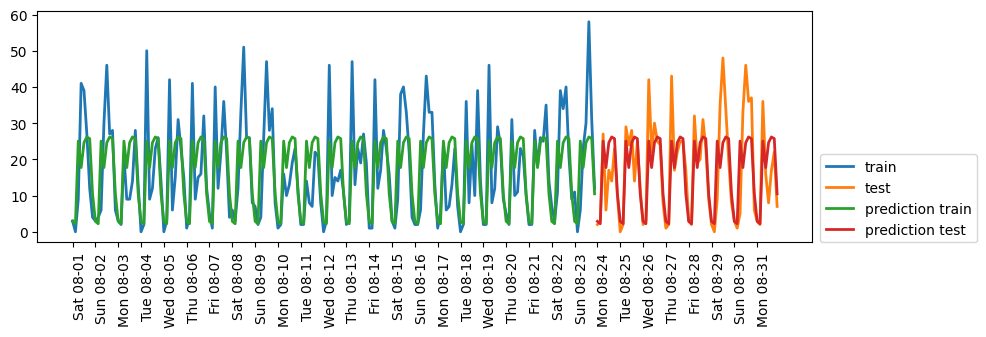

In [ ]:
X_hour = citibike.index.hour.to_numpy().reshape(-1, 1)
eval_on_features(X_hour, y, regressor)

- Time is decomposed into meaningful components (e.g., hour of day, day of week).
- This introduces domain-relevant structure into the feature space.

Test-set R^2:  0.8419488587966024


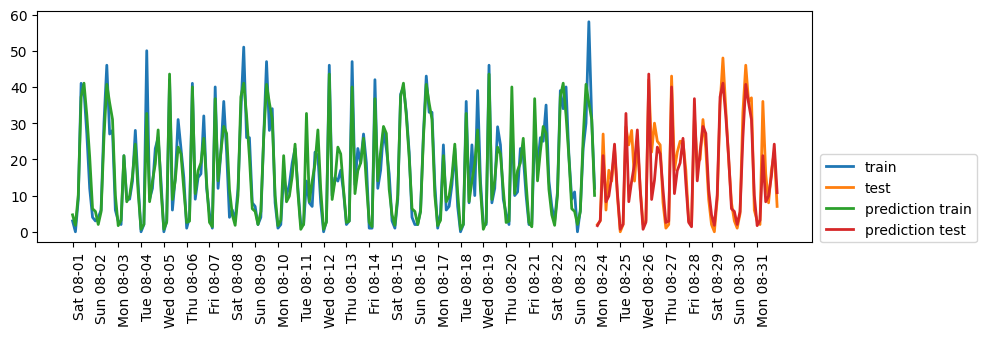

In [ ]:
X_hour_week = np.hstack([citibike.index.dayofweek.to_numpy().reshape(-1, 1),
                         X_hour])
eval_on_features(X_hour_week, y, regressor)

Test-set R^2:  0.13204157262163163


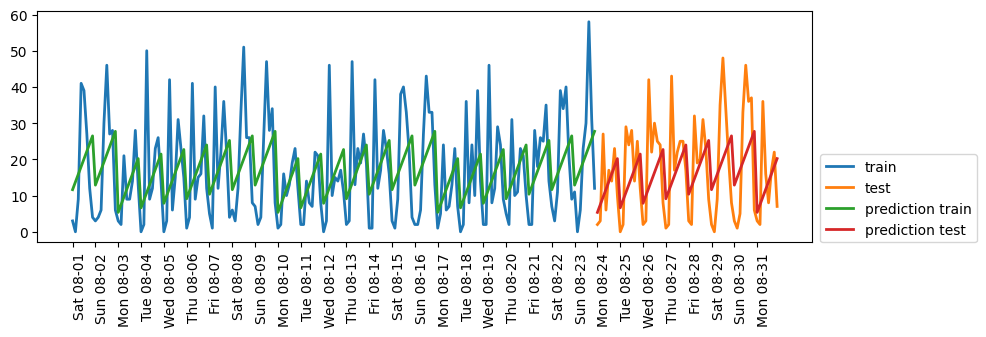

In [ ]:
eval_on_features(X_hour_week, y, LinearRegression())

Test-set R^2:  0.6220236396520935


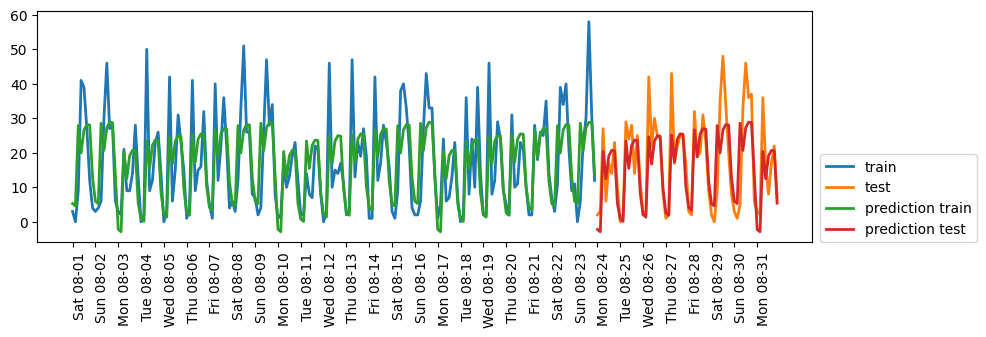

In [ ]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
X_hour_week_onehot = enc.fit_transform(X_hour_week).toarray()

eval_on_features(X_hour_week_onehot, y, LinearRegression())

### Key Takeaway

This example demonstrates that:

- The choice of feature representation is often more important than the choice of model.
- Raw time indices are not informative for learning periodic patterns.
- Feature engineering (e.g., decomposition, encoding) enables even simple models to capture complex structures.

# Final summary

## Univariate nonlinear transformations
Use them when a variable is skewed, count-like, badly scaled, or periodic.

Examples:
- `log1p(x)` for counts
- `sqrt(x)` for counts or positive values
- `sin` / `cos` for periodic structure

## Automatic feature selection
Useful when many variables may be noisy or irrelevant

Example
- `SelectPercentile`

## Model-based feature selection
Let a model decide which variables matter jointly

Examples:
- `Lasso`
- `SelectFromModel`
- tree-based models

## Expert knowledge
Often the most important source of useful features in social data.

Examples:
- age squared
- log income
- survey-scale construction
- response-process indicators

---

Feature engineering is not only about generating more variables.  
It is about finding a representation of the data that better matches the structure of the problem.
